In [ ]:
from importlib import reload
import utils
reload(utils)

In [ ]:
from utils import load_data, split_data, preprocess
from utils import preprocess_v1, preprocess_v2, preprocess_v3, preprocess_v4
from utils import max_features_svm, prepare_plot_data

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
df, X, y = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print("Liczba przykładów:")
print(f"  treningowych   {len(y_train):,}")
print(f"  walidacyjnych  {len(y_val):,}")
print(f"  testowych      {len(y_test):,}")

Liczba przykładów:
  treningowych   36,876
  walidacyjnych  7,902
  testowych      7,903


In [ ]:
X_train_base = X_train.apply(preprocess)
X_val_base = X_val.apply(preprocess)
X_test_base = X_test.apply(preprocess)

In [ ]:
X_train_v1 = X_train.apply(preprocess_v1)
X_val_v1 = X_val.apply(preprocess_v1)
X_test_v1 = X_test.apply(preprocess_v1)

In [ ]:
X_train_v2 = X_train.apply(preprocess_v2)
X_val_v2 = X_val.apply(preprocess_v2)
X_test_v2 = X_test.apply(preprocess_v2)

In [ ]:
X_train_v3 = X_train.apply(preprocess_v3)
X_val_v3 = X_val.apply(preprocess_v3)
X_test_v3 = X_test.apply(preprocess_v3)

In [ ]:
X_train_v4 = X_train.apply(preprocess_v4)
X_val_v4 = X_val.apply(preprocess_v4)
X_test_v4 = X_test.apply(preprocess_v4)

### Eksperyment 2.1: mocniejszy model
...

In [10]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

In [ ]:
svm_pipeline.fit(X_train_base, y_train)
y_val_pred_svm_base = svm_pipeline.predict(X_val_base)
f1_macro_svm_base = f1_score(y_val, y_val_pred_svm_base, average='macro')

print(classification_report(y_val, y_val_pred_svm_base))
print(f"F1 macro: {f1_macro_svm_base:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.81      0.78      0.79       576
             Bipolar       0.83      0.69      0.75       416
          Depression       0.71      0.72      0.71      2311
              Normal       0.88      0.94      0.91      2451
Personality disorder       0.83      0.60      0.70       162
              Stress       0.66      0.51      0.57       388
            Suicidal       0.67      0.67      0.67      1598

            accuracy                           0.77      7902
           macro avg       0.77      0.70      0.73      7902
        weighted avg       0.77      0.77      0.77      7902

F1 macro: 0.73


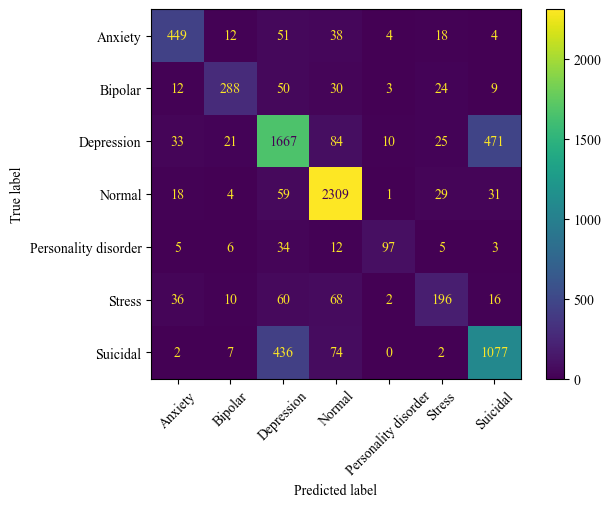

In [ ]:
cm_svm = confusion_matrix(y_val, y_val_pred_svm_base)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_svm_base,
    xticks_rotation=45)

In [ ]:
print("Baseline:")
f1_scores_svm_base = max_features_svm(X_train_base, X_val_base, y_train, y_val)

In [ ]:
print("Preprocessing v1:")
f1_scores_svm_v1 = max_features_svm(X_train_v1, X_val_v1, y_train, y_val)

In [ ]:
print("Preprocessing v2:")
f1_scores_svm_v2 = max_features_svm(X_train_v2, X_val_v2, y_train, y_val)

In [ ]:
print("Preprocessing v3:")
f1_scores_svm_v3 = max_features_svm(X_train_v3, X_val_v3, y_train, y_val)

In [ ]:
print("Preprocessing v4:")
f1_scores_svm_v4 = max_features_svm(X_train_v4, X_val_v4, y_train, y_val)

In [ ]:
# wizualizacja wpływu max_features na F1 macro (model=SVM)
x_base, y_base = prepare_plot_data(f1_scores_svm_base)
x_v1, y_v1 = prepare_plot_data(f1_scores_svm_v1)
x_v2, y_v2 = prepare_plot_data(f1_scores_svm_v2)
x_v3, y_v3 = prepare_plot_data(f1_scores_svm_v3)
x_v4, y_v4 = prepare_plot_data(f1_scores_svm_v4)

plt.figure(figsize=(10, 6))
plt.plot(x_base, y_base, marker='o', label='Baseline')
plt.plot(x_v1, y_v1, marker='o', label='Preprocessing V1')
plt.plot(x_v2, y_v2, marker='o', label='Preprocessing V2')
plt.plot(x_v3, y_v3, marker='o', label='Preprocessing V3')
plt.plot(x_v4, y_v4, marker='o', label='Preprocessing V4')

plt.title("Impact of max_features on F1 Macro (SVM)")
plt.xlabel("max_features")
plt.ylabel("F1 Macro")

plt.xticks(
    [500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500],
    ['500','1000','1500','2000','2500','3000','3500','4000','4500','5000','All']
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()